# Lookback Robustness Analysis

**Goal:** Find robust *ranges* of lookback periods for the daily trend-following
breakout strategy (no COT filters). A robust range is a contiguous stretch of
lookbacks that all deliver CAGR above 20% with statistical confidence.

**Why ranges, not point estimates:** Picking "the best" lookback (e.g. 19 days)
is almost certainly overfit. If 20–30 days all perform well, the edge is
structural and not parameter-sensitive.

**Method:**
1. Performance surface: every lookback 5–100 across 48 markets (full period)
2. Block-bootstrap 95% CIs for Sharpe and CAGR
3. Identify robust ranges (5+ consecutive lookbacks with lower CI of CAGR >= 20%)
4. Walk-forward validation: train-identified ranges tested OOS across 4 windows

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.getcwd())

from lookback_robustness import (
    run_performance_surface, find_robust_ranges,
    run_walk_forward_validation,
    ALL_LOOKBACKS, MIN_CAGR_TARGET, WF_WINDOWS, INITIAL_CAPITAL,
)
from backtest_engine.data import load_cot_data

pd.set_option("display.max_rows", 110)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="darkgrid")

print("Imports OK")

Imports OK


In [2]:
cot_df = load_cot_data(os.path.join(PROJECT_ROOT, "cot_data.json"))
markets = sorted(cot_df["Market"].unique().tolist())
print(f"Loaded {len(cot_df):,} rows, {len(markets)} markets")
print(f"Date range: {cot_df['Date'].min().date()} to {cot_df['Date'].max().date()}")

Loaded 51,893 rows, 48 markets
Date range: 2022-01-03 to 2026-04-02


---
## Part 1 — Performance Surface (Full Period)

In [3]:
surface, pnl_store = run_performance_surface(
    cot_df, markets,
    lookbacks=ALL_LOOKBACKS,
    start_date="2022-01-01", end_date="2026-04-02",
    do_bootstrap=True,
    verbose=True,
)

Pre-computing indicators …
  48 markets ready
  Lookback   5d  (1/96)
  Lookback  15d  (11/96)
  Lookback  25d  (21/96)
  Lookback  35d  (31/96)
  Lookback  45d  (41/96)
  Lookback  55d  (51/96)
  Lookback  65d  (61/96)
  Lookback  75d  (71/96)
  Lookback  85d  (81/96)
  Lookback  95d  (91/96)
  Lookback 100d  (96/96)

  Viable lookbacks (lower CI of CAGR ≥ 20.0%): 52 / 96


### CAGR vs Lookback (with 95% bootstrap CI)

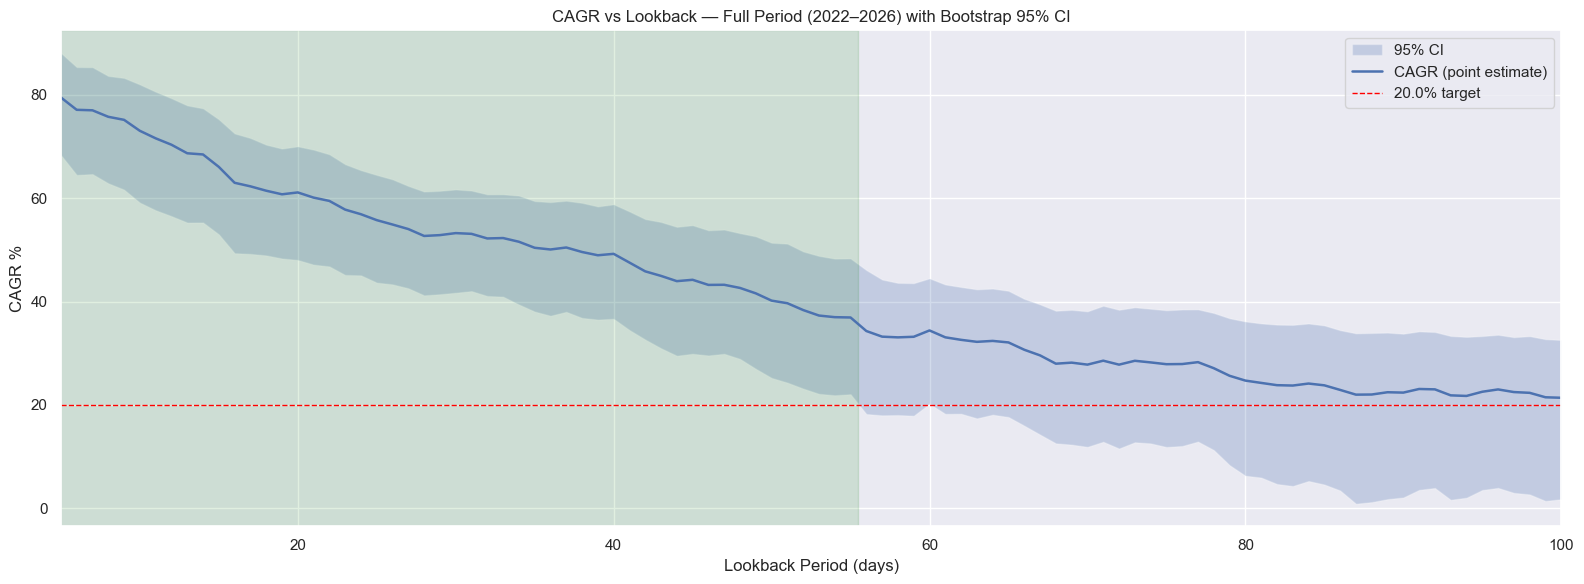

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
lb = surface.index.values

ax.fill_between(lb, surface["cagr_lo"], surface["cagr_hi"],
                alpha=0.25, label="95% CI")
ax.plot(lb, surface["cagr"], linewidth=1.8, label="CAGR (point estimate)")
ax.axhline(MIN_CAGR_TARGET, color="red", linestyle="--", linewidth=1,
           label=f"{MIN_CAGR_TARGET}% target")

# Shade robust ranges
ranges = find_robust_ranges(surface)
for r in ranges:
    ax.axvspan(r["start"] - 0.5, r["end"] + 0.5, alpha=0.12, color="green")

ax.set_xlabel("Lookback Period (days)")
ax.set_ylabel("CAGR %")
ax.set_title("CAGR vs Lookback — Full Period (2022–2026) with Bootstrap 95% CI")
ax.legend()
ax.set_xlim(5, 100)
plt.tight_layout()
plt.show()

### Sharpe Ratio vs Lookback (with 95% bootstrap CI)

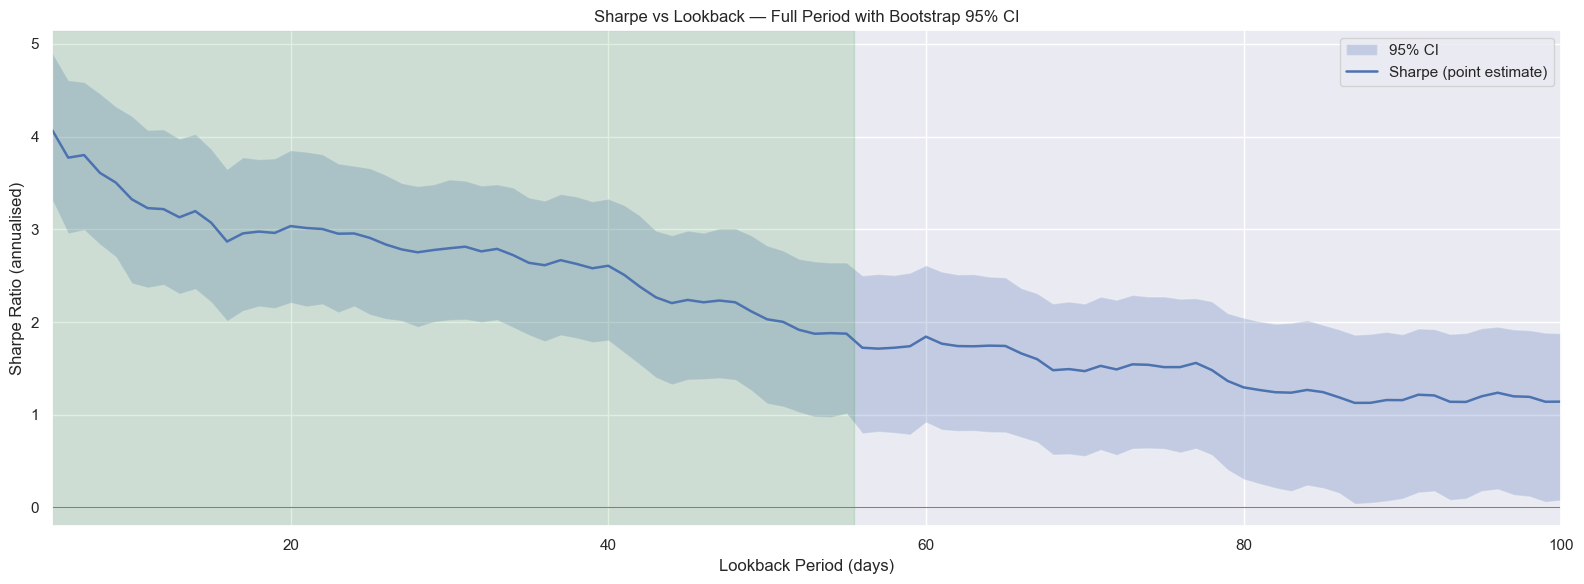

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(lb, surface["sharpe_lo"], surface["sharpe_hi"],
                alpha=0.25, label="95% CI")
ax.plot(lb, surface["sharpe"], linewidth=1.8, label="Sharpe (point estimate)")
ax.axhline(0, color="gray", linewidth=0.8)

for r in ranges:
    ax.axvspan(r["start"] - 0.5, r["end"] + 0.5, alpha=0.12, color="green")

ax.set_xlabel("Lookback Period (days)")
ax.set_ylabel("Sharpe Ratio (annualised)")
ax.set_title("Sharpe vs Lookback — Full Period with Bootstrap 95% CI")
ax.legend()
ax.set_xlim(5, 100)
plt.tight_layout()
plt.show()

### Max Drawdown vs Lookback

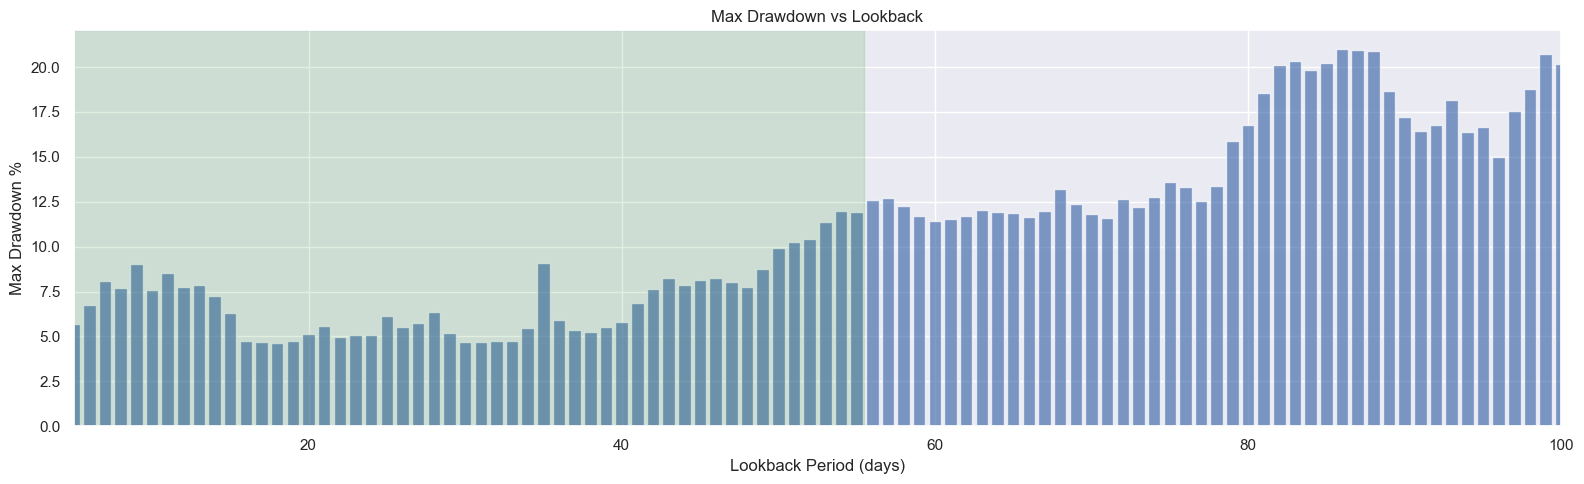

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(lb, surface["max_dd_pct"], width=0.8, alpha=0.7)
for r in ranges:
    ax.axvspan(r["start"] - 0.5, r["end"] + 0.5, alpha=0.12, color="green")
ax.set_xlabel("Lookback Period (days)")
ax.set_ylabel("Max Drawdown %")
ax.set_title("Max Drawdown vs Lookback")
ax.set_xlim(5, 100)
plt.tight_layout()
plt.show()

### Combined: Sharpe, CAGR, and Win Rate

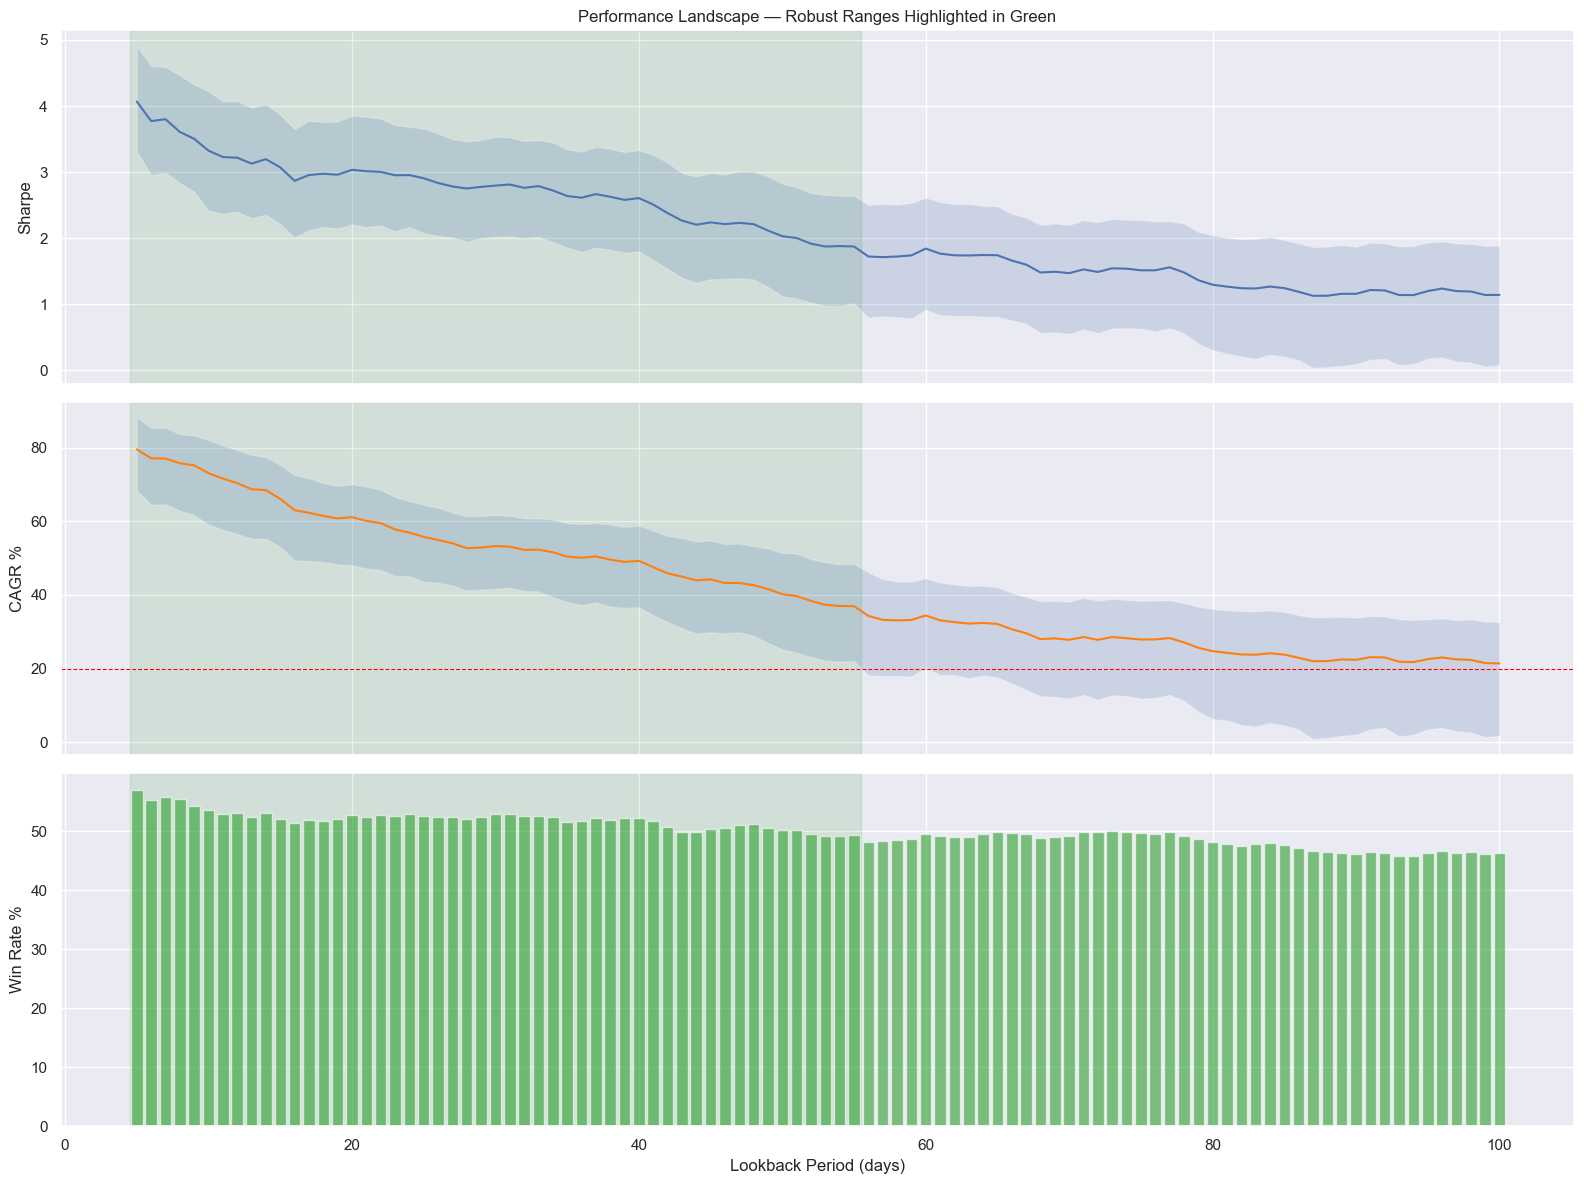

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for r in ranges:
    for ax in axes:
        ax.axvspan(r["start"] - 0.5, r["end"] + 0.5, alpha=0.10, color="green")

axes[0].fill_between(lb, surface["sharpe_lo"], surface["sharpe_hi"], alpha=0.2)
axes[0].plot(lb, surface["sharpe"], linewidth=1.5)
axes[0].set_ylabel("Sharpe")
axes[0].set_title("Performance Landscape — Robust Ranges Highlighted in Green")

axes[1].fill_between(lb, surface["cagr_lo"], surface["cagr_hi"], alpha=0.2)
axes[1].plot(lb, surface["cagr"], linewidth=1.5, color="tab:orange")
axes[1].axhline(MIN_CAGR_TARGET, color="red", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("CAGR %")

axes[2].bar(lb, surface["win_rate"], width=0.8, alpha=0.6, color="tab:green")
axes[2].set_ylabel("Win Rate %")
axes[2].set_xlabel("Lookback Period (days)")

plt.tight_layout()
plt.show()

---
## Part 2 — Robust Ranges

In [8]:
ranges = find_robust_ranges(surface)

if ranges:
    print(f"Found {len(ranges)} robust range(s) (>= 5 consecutive viable lookbacks):\n")
    for i, r in enumerate(ranges):
        print(f"  Range {i+1}: {r['start']}d – {r['end']}d  "
              f"(width {r['width']}d)")
        print(f"    Avg Sharpe:  {r['avg_sharpe']:.2f}")
        print(f"    Avg CAGR:    {r['avg_cagr']:.1f}%")
        print(f"    Avg Max DD:  {r['avg_max_dd']:.1f}%")
        print(f"    Avg Trades:  {r['avg_trades']:.0f}")
        print()
else:
    print("No robust ranges found. No contiguous stretch of 5+ lookbacks")
    print(f"has bootstrap lower CI of CAGR >= {MIN_CAGR_TARGET}%.")
    print("\nThis means the 20% target is not reliably achievable")
    print("at any specific lookback range with statistical confidence.")

Found 1 robust range(s) (>= 5 consecutive viable lookbacks):

  Range 1: 5d – 55d  (width 51d)
    Avg Sharpe:  2.75
    Avg CAGR:    55.0%
    Avg Max DD:  7.0%
    Avg Trades:  1526



### Viability heatstrip

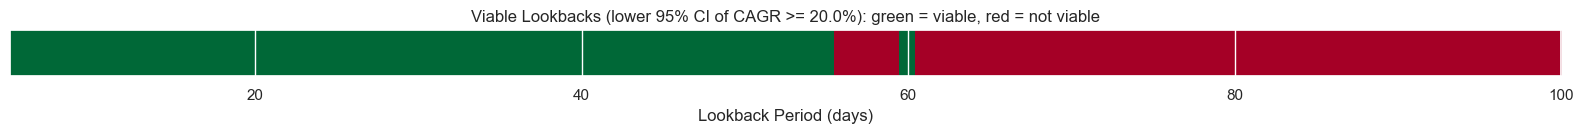

In [9]:
fig, ax = plt.subplots(figsize=(16, 1.5))
viable_arr = surface["viable"].values.astype(float).reshape(1, -1)
ax.imshow(viable_arr, aspect="auto", cmap="RdYlGn",
          extent=[5, 100, 0, 1], interpolation="nearest")
ax.set_xlabel("Lookback Period (days)")
ax.set_yticks([])
ax.set_title(f"Viable Lookbacks (lower 95% CI of CAGR >= {MIN_CAGR_TARGET}%): "
             f"green = viable, red = not viable")
plt.tight_layout()
plt.show()

### Full metrics table (top 30 by CAGR)

In [10]:
display_cols = ["sharpe", "cagr", "cagr_lo", "cagr_hi",
                "max_dd_pct", "win_rate", "trades", "profit_factor", "viable"]
surface[display_cols].sort_values("cagr", ascending=False).head(30)

,sharpe,cagr,cagr_lo,cagr_hi,max_dd_pct,win_rate,trades,profit_factor,viable
lookback,,,,,,,,,
5,4.07,79.51,68.38,88.13,5.71,57.02,2264,2.02,True
6,3.77,77.12,64.52,85.40,6.73,55.24,2368,1.90,True
7,3.80,77.02,64.68,85.37,8.10,55.79,2298,1.94,True
8,3.61,75.77,62.90,83.68,7.69,55.52,2257,1.92,True
9,3.50,75.18,61.67,83.29,9.05,54.25,2234,1.90,True
10,3.32,73.06,59.16,82.03,7.59,53.57,2212,1.84,True
11,3.23,71.60,57.69,80.63,8.52,52.86,2151,1.83,True
12,3.22,70.36,56.55,79.36,7.74,53.04,2102,1.83,True
13,3.13,68.71,55.30,77.98,7.88,52.33,2037,1.80,True


---
## Part 3 — Walk-Forward Validation

Does the range identified on training data hold up out-of-sample?

**Three portfolios compared OOS:**
- **(A) Range portfolio:** equal-weight lookbacks inside the train-identified robust ranges
- **(B) Best single lookback:** highest Sharpe from training (the overfitting-prone pick)
- **(C) All-lookback portfolio:** equal-weight all 96 lookbacks (the diversified baseline)

In [11]:
wf_results = run_walk_forward_validation(
    cot_df, markets,
    windows=WF_WINDOWS,
    lookbacks=ALL_LOOKBACKS,
    verbose=True,
)

Pre-computing indicators …

WF-1  Train → 2023-06-30  Test 2023-07-01 → 2024-03-31
  Train ranges: [{'start': 5, 'end': 67, 'width': 63, 'avg_sharpe': np.float64(3.4279739156969957), 'avg_cagr': np.float64(127.59545727329456), 'avg_max_dd': np.float64(6.4425522067267815), 'avg_trades': np.float64(404.26984126984127)}]
  Best single LB (train Sharpe): 8d
  OOS Sharpe  →  Range: 3.72  Best-8d: 3.86  All: 3.35
  OOS CAGR    →  Range: 182.9%  Best-8d: 299.9%  All: 135.3%

WF-2  Train → 2024-03-31  Test 2024-04-01 → 2024-12-31
  Train ranges: [{'start': 5, 'end': 68, 'width': 64, 'avg_sharpe': np.float64(3.5376551196866943), 'avg_cagr': np.float64(95.85077655497028), 'avg_max_dd': np.float64(6.676653352997164), 'avg_trades': np.float64(694.3125)}]
  Best single LB (train Sharpe): 5d
  OOS Sharpe  →  Range: 1.63  Best-5d: 2.91  All: 1.37
  OOS CAGR    →  Range: 68.0%  Best-5d: 206.4%  All: 47.6%

WF-3  Train → 2024-12-31  Test 2025-01-01 → 2025-09-30
  Train ranges: [{'start': 5, 'end': 65, 

In [13]:
wf_rows = []
for wr in wf_results:
    base = {
        "Window": wr["window"],
        "Test Period": f"{wr['test_start']} → {wr['test_end']}",
        "Train Ranges": ", ".join(
            f"{r['start']}–{r['end']}d" for r in wr["train_ranges"]
        ) if wr["train_ranges"] else "None",
        "Best Single LB": f"{wr['best_single_lb']}d",
    }
    for label, key in [("A: Range", "portfolio_A_range"),
                       ("B: Best Single", "portfolio_B_best"),
                       ("C: All LBs", "portfolio_C_all")]:
        m = wr[key]
        base[f"{label} Sharpe"] = f"{m['sharpe']:.2f}"
        base[f"{label} CAGR"] = f"{m['cagr']:.1f}%"
        base[f"{label} MaxDD"] = f"{m['max_dd_pct']:.1f}%"
    wf_rows.append(base)

wf_df = pd.DataFrame(wf_rows)
wf_df

,Window,Test Period,Train Ranges,Best Single LB,A: Range Sharpe,A: Range CAGR,A: Range MaxDD,B: Best Single Sharpe,B: Best Single CAGR,B: Best Single MaxDD,C: All LBs Sharpe,C: All LBs CAGR,C: All LBs MaxDD
0,WF-1,2023-07-01 → 2024-03-31,5–67d,8d,3.72,182.9%,8.7%,3.86,299.9%,11.4%,3.35,135.3%,9.2%
1,WF-2,2024-04-01 → 2024-12-31,5–68d,5d,1.63,68.0%,11.8%,2.91,206.4%,7.4%,1.37,47.6%,13.2%
2,WF-3,2025-01-01 → 2025-09-30,5–65d,5d,0.98,44.3%,20.5%,1.32,80.9%,16.5%,0.96,39.0%,23.0%
3,WF-4,2025-10-01 → 2026-04-02,5–52d,5d,2.30,135.5%,12.0%,2.63,221.1%,17.1%,1.71,79.6%,16.2%


### Walk-forward OOS equity curves

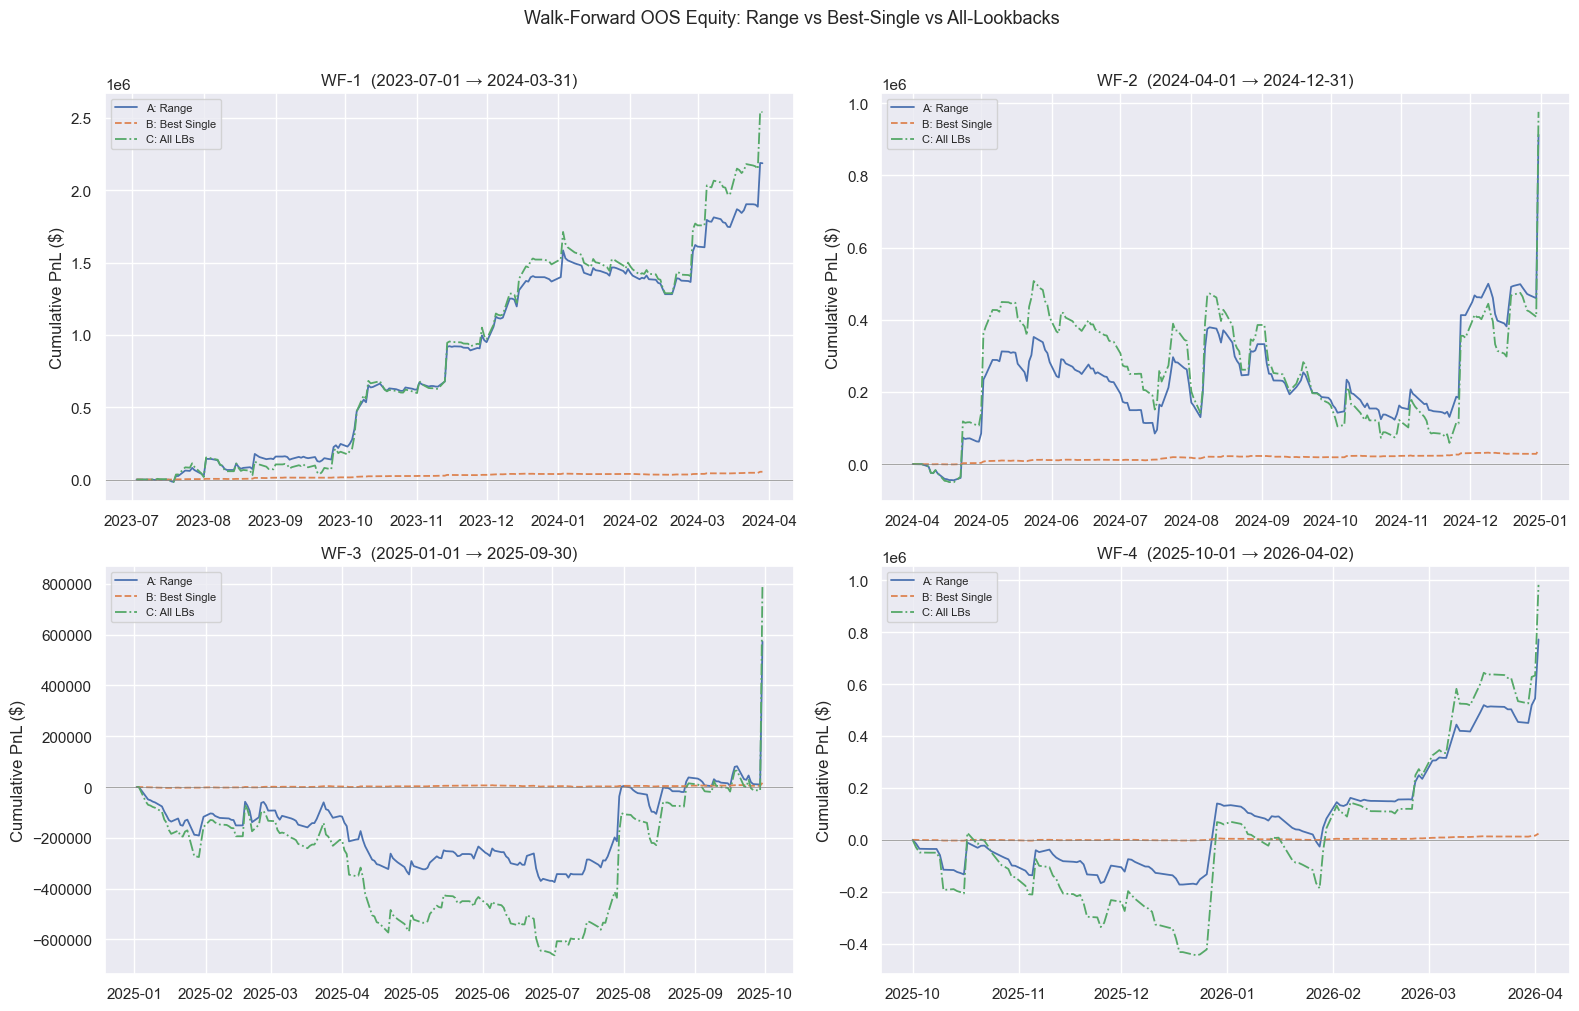

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (wr, ax) in enumerate(zip(wf_results, axes.flat)):
    for pnl_key, label, ls in [
        ("pnl_range", "A: Range", "-"),
        ("pnl_best",  "B: Best Single", "--"),
        ("pnl_all",   "C: All LBs", "-."),
    ]:
        pnl = wr[pnl_key]
        if pnl.empty:
            continue
        cum = pnl.cumsum()
        ax.plot(cum.index, cum.values, label=label, linestyle=ls, linewidth=1.3)

    ax.set_title(f"{wr['window']}  ({wr['test_start']} → {wr['test_end']})")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", linewidth=0.5)

fig.suptitle("Walk-Forward OOS Equity: Range vs Best-Single vs All-Lookbacks",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Aggregate walk-forward comparison

In [15]:
# Pool all OOS PnL across windows for each portfolio
agg = {}
for key, label in [("pnl_range", "A: Range"),
                    ("pnl_best",  "B: Best Single"),
                    ("pnl_all",   "C: All LBs")]:
    parts = [wr[key] for wr in wf_results if not wr[key].empty]
    if parts:
        pooled = pd.concat(parts).sort_index()
    else:
        pooled = pd.Series(dtype=float)
    agg[label] = pooled

print("Aggregate OOS performance (pooled across all 4 windows):\n")
for label, pnl in agg.items():
    if pnl.empty:
        print(f"  {label}: No data")
        continue
    total_days = (pnl.index[-1] - pnl.index[0]).days
    years = max(total_days / 365.25, 0.01)
    dr = pnl / INITIAL_CAPITAL
    std = dr.std()
    sharpe = (dr.mean() / std) * np.sqrt(252) if std > 0 else 0
    total_ret = pnl.sum()
    eq = INITIAL_CAPITAL + pnl.cumsum()
    peak = eq.cummax()
    dd = ((eq - peak) / peak).min() * 100
    print(f"  {label}:")
    print(f"    Sharpe: {sharpe:.2f}")
    print(f"    Total PnL: ${total_ret:,.0f}")
    print(f"    Max DD: {abs(dd):.1f}%")
    print()

Aggregate OOS performance (pooled across all 4 windows):

  A: Range:
    Sharpe: 2.15
    Total PnL: $4,444,120
    Max DD: 56.6%

  B: Best Single:
    Sharpe: 2.72
    Total PnL: $133,455
    Max DD: 11.4%

  C: All LBs:
    Sharpe: 1.83
    Total PnL: $5,295,154
    Max DD: 68.8%



---
## Part 4 — Conclusion

In [16]:
print("=" * 60)
print("CONCLUSION — Lookback Robustness Analysis")
print("=" * 60)

if ranges:
    print(f"\nRobust range(s) found (full period, bootstrap-validated):")
    for r in ranges:
        print(f"  {r['start']}d – {r['end']}d  "
              f"(Sharpe {r['avg_sharpe']:.2f}, CAGR {r['avg_cagr']:.1f}%, "
              f"Max DD {r['avg_max_dd']:.1f}%)")
else:
    print(f"\nNo robust ranges found where CAGR lower CI >= {MIN_CAGR_TARGET}%.")

print(f"\nWalk-forward consistency:")
for wr in wf_results:
    rng_str = ", ".join(f"{r['start']}-{r['end']}d" for r in wr["train_ranges"]) if wr["train_ranges"] else "None"
    print(f"  {wr['window']}: Train ranges = {rng_str}")

print(f"\nKey insight: if the same lookback ranges appear consistently")
print(f"across training windows, they represent a genuine structural")
print(f"feature. If they shift dramatically, diversifying across all")
print(f"lookbacks is the safer approach.")

CONCLUSION — Lookback Robustness Analysis

Robust range(s) found (full period, bootstrap-validated):
  5d – 55d  (Sharpe 2.75, CAGR 55.0%, Max DD 7.0%)

Walk-forward consistency:
  WF-1: Train ranges = 5-67d
  WF-2: Train ranges = 5-68d
  WF-3: Train ranges = 5-65d
  WF-4: Train ranges = 5-52d

Key insight: if the same lookback ranges appear consistently
across training windows, they represent a genuine structural
feature. If they shift dramatically, diversifying across all
lookbacks is the safer approach.
